# Phase 1: Data Exploration for Total Perspective Vortex
This notebook explores the PhysioNet EEG Motor Movement/Imagery Dataset. 

**Motor Execution vs. Motor Imagery:**
* **Motor Execution (ME):** The subject physically performs a movement (e.g., opening/closing a fist). This generates actual sensory-motor cortex activation.
* **Motor Imagery (MI):** The subject *imagines* performing the movement without any actual muscle activity. This is the core of our BCI pipeline. We aim to detect the Event-Related Desynchronization/Synchronization (ERD/ERS) in the alpha and beta bands that occurs during the *thought* of movement.

In [ ]:
import os
import mne
import matplotlib.pyplot as plt
import numpy as np

# Suppress some MNE warnings for cleaner notebook output
mne.set_log_level('WARNING')

# Define exclusions based on known dataset issues
# Subject 88: Sampled at 128 Hz instead of 160 Hz
# Subjects 38, 89, 92, 100, 104, 106: Known annotation/event errors
EXCLUDED_SUBJECTS = [38, 88, 89, 92, 100, 104, 106]

# 106 ok, 

# Base directory for the unzipped dataset
BASE_DATA_PATH = "./data/files"

In [ ]:
def load_eeg_data(subject_id, run_id, base_path=BASE_DATA_PATH):
    """
    Loads an EDF+ file for a specific subject and run, verifying 
        metadata constraints.
    args:
        subject_id (int): The subject number (e.g., 1 for S001)
        run_id (int): The run number (e.g., 4 for R04)
        base_path (str): The base directory where the dataset is stored.
    returns:
        raw (mne.io.Raw): The loaded EEG data with verified metadata 
            in form of an MNE Raw object.
    """

    if subject_id in EXCLUDED_SUBJECTS:
        raise ValueError(f"Subject {subject_id} is excluded from this analysis due to dataset anomalies.")

    # Format strings to match PhysioNet standard (e.g., S001/S001R04.edf)
    subj_str = f"S{subject_id:03d}"
    run_str = f"R{run_id:02d}"
    file_path = os.path.join(base_path, subj_str, f"{subj_str}{run_str}.edf")

    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found at: {file_path}")

    # Load the EDF file using MNE this should respect path standards (e.g., S001/S001R04.edf)
    print(f"Loading data from {file_path}...")
    raw = mne.io.read_raw_edf(file_path, preload=True)

    # 1. Verify Sampling Rate
    if raw.info['sfreq'] != 160.0:
        raise ValueError(f"Sampling rate mismatch! Expected 160 Hz, got {raw.info['sfreq']} Hz")

    # 2. Verify Channel Count
    if len(raw.ch_names) != 64:
        raise ValueError(f"Channel count mismatch! Expected 64, got {len(raw.ch_names)}")

    # 3. Standardize Channel Names & Set Montage
    # PhysioNet EDF files often have trailing dots in channel names (e.g., 'Fc5.')
    mne.datasets.eegbci.standardize(raw) 
    # Set the standard 10-20 montage for EEG channel locations
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)

    print("Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.")
    return raw

In [ ]:
def extract_and_map_events(raw, run_id):
    """
    Extracts events from annotations and maps them to specific tasks based on the run number.
    args:
        raw (mne.io.Raw): The loaded EEG data with annotations.
        run_id (int): The run number to determine task mapping.
    returns:
        events (np.ndarray): Array of events extracted from annotations.
        event_dict (dict): Mapping of event codes to their descriptions.
        descriptions (dict): Contextual descriptions for the events.
    """
    # Base mapping: T0 is always rest
    # t0 is the baseline/rest period.
    # t1  is 
    event_id = {"T0": 1, "T1": 2, "T2": 3}

    # Contextual descriptions for our plots and understanding
    descriptions = {1: 'Rest (T0)'}

    if run_id in [4, 8, 12]:
        descriptions[2] = 'Imagine Left Fist (T1)'
        descriptions[3] = 'Imagine Right Fist (T2)'
    elif run_id in [6, 10, 14]:
        descriptions[2] = 'Imagine Both Fists (T1)'
        descriptions[3] = 'Imagine Both Feet (T2)'
    else:
        # For execution runs or baseline runs (not explicitly requested in prompt, but handled safely)
        descriptions[2] = 'Task 1 (T1)'
        descriptions[3] = 'Task 2 (T2)'

    # Extract events from the EDF+ annotations
    events, event_dict = mne.events_from_annotations(raw, event_id=event_id)

    print(f"Mapped Events for Run {run_id}:")
    for event_code, desc in descriptions.items():
        print(f"  Code {event_code}: {desc}")

    return events, event_dict, descriptions

In [4]:
# Parameters for our test subject
SUBJECT_TO_TEST = 1
RUN_TO_TEST = 4  # Motor Imagery: Left vs Right Fist

# 1. Load the data
raw = load_eeg_data(SUBJECT_TO_TEST, RUN_TO_TEST)


Loading data from ./data/files/S001/S001R04.edf...
Metadata verified: 160 Hz sampling rate, 64 channels, standard_1020 montage applied.


In [7]:

# 2. Map the events
events, event_dict, event_descriptions = extract_and_map_events(raw, RUN_TO_TEST)


Mapped Events for Run 4:
  Code 1: Rest (T0)
  Code 2: Imagine Left Fist (T1)
  Code 3: Imagine Right Fist (T2)


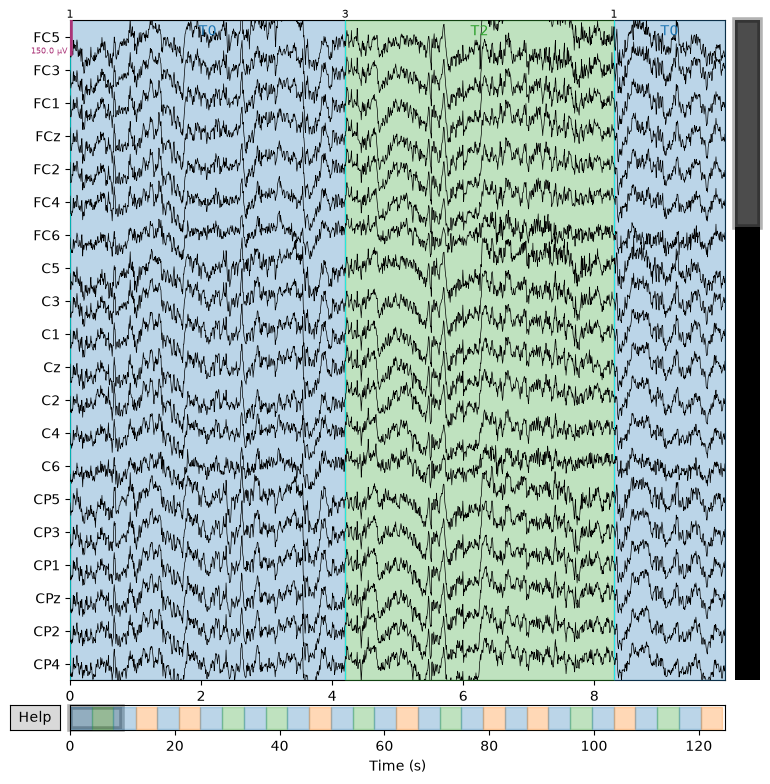

In [8]:


# 3. Visualize Raw Continuous Signal with Events
# Note: In a Jupyter Notebook, %matplotlib widget or qt can make this fully interactive.
# We set scalings='auto' or a specific microvolt dictionary so signals don't overlap.
fig_raw = raw.plot(
    events=events, 
    start=0, 
    duration=10, 
    n_channels=20, 
    scalings={'eeg': 75e-6}, # Scale to 75 microvolts for better visibility
    title=f"Subject {SUBJECT_TO_TEST} Run {RUN_TO_TEST} - Raw EEG (First 10s)",
    show=True
)


/Users/alex/brige-projects/programing/42/projects/Total-Perspective-Vortex/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


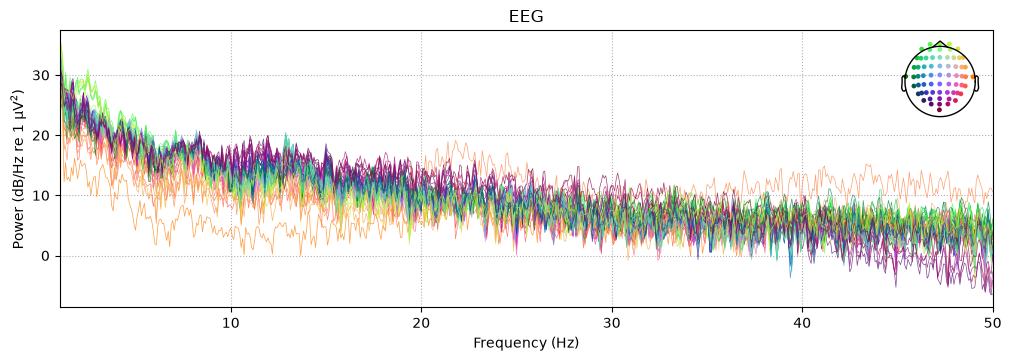

<Figure size 1000x300 with 0 Axes>

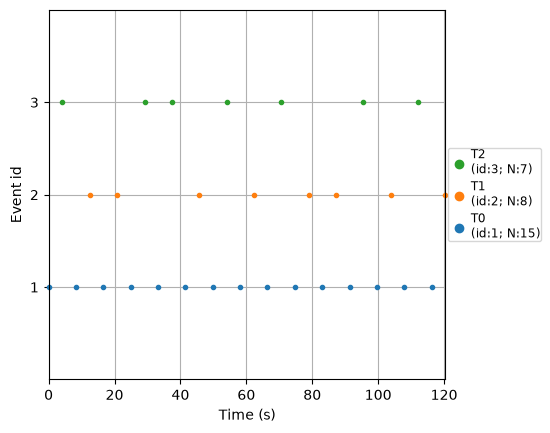

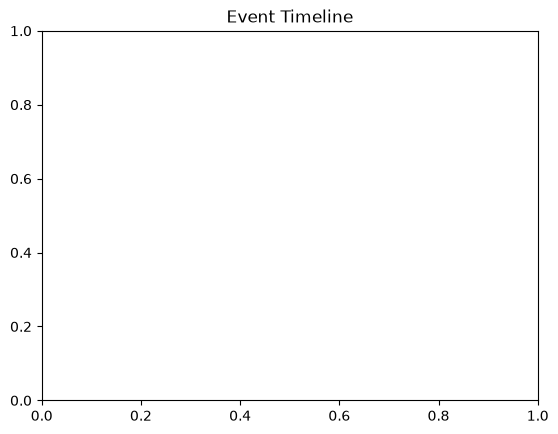

In [ ]:

# 4. Visualize Power Spectral Density (PSD)
# We limit frequencies between 1 Hz and 50 Hz to focus on Alpha (8-13 Hz) and Beta (14-30 Hz)
# This is crucial for feature selection in Phase 1.
# !fmin:  means the minimum frequency to include in the PSD calculation
# ! fmax:  means the maximum frequency to include in the PSD calculation
fig_psd = raw.compute_psd(fmin=1.0, fmax=50.0).plot(
    # picks means which channels to include in the PSD calculation. 
        # 'eeg' includes all EEG channels.
    picks='eeg', 
    # exclude means which channels to exclude from the PSD calculation. 
        # 'bads' includes all channels marked as bad in the raw.info['bads'] list.
    exclude='bads',
    show=True
)

#===============================================================================
#                 event timing
#===============================================================================
# Add supplementary static visualization of event timing using Matplotlib
plt.figure(figsize=(10, 3))
# viz.plot_events is a static visualization of events over time,
#  useful for quick inspection.
mne.viz.plot_events(
    # events: The array of events extracted from the raw data.
        # e.g
    events, 
    sfreq=raw.info['sfreq'], 
    first_samp=raw.first_samp, 
    event_id=event_dict
)
plt.title("Event Timeline")
plt.show()